In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
import pickle

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [2]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled


In [3]:
# Find and load all burst_metrics_PF.pkl files
pattern = os.path.join(data_folder, 'CKII**', 'burst_metrics_PF.pkl')
pkl_files = glob.glob(pattern, recursive=True)
print(f'Found {len(pkl_files)} burst_metrics_PF files:')
for f in pkl_files:
    print(f'  {f}')

# User setting: whether to include simple bursts in plots
include_simple_bursts = False

# Pool data
conditions = ['run_in', 'run_out', 'rest_in', 'rest_out']
metric_specs = [
    ('n_spikes', 'Spks./burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

metric_data_pooled = {
    'complex': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs},
    'simple': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs},
}
cond_counts_pooled = {
    'complex': {cond: [] for cond in conditions},
    'simple': {cond: [] for cond in conditions},
}
min_bursts_per_condition = 5

for pkl_path in pkl_files:
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    metric_data = data['metric_data']
    cond_counts = data['cond_counts']
    min_bursts_per_condition = data.get('min_bursts_per_condition', 5)
    
    dataset_name = os.path.basename(os.path.dirname(pkl_path))
    n_cells = len(metric_data['complex']['n_spikes']['run_in'])
    
    for burst_type in ['complex', 'simple']:
        for metric, _ in metric_specs:
            for cond in conditions:
                metric_data_pooled[burst_type][metric][cond].extend(
                    metric_data[burst_type][metric][cond]
                )
        for cond in conditions:
            cond_counts_pooled[burst_type][cond].extend(cond_counts[burst_type][cond])
    
    print(f'Loaded {dataset_name}: {n_cells} cells')

# Print summary
print(f'\nTotal pooled cells:')
n = len(metric_data_pooled['complex']['n_spikes']['run_in'])
print(f'  {n} cells')
print(f'\ninclude_simple_bursts = {include_simple_bursts}')

Found 4 burst_metrics_PF files:
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce21_PR_20250806/burst_metrics_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce45_PX_20260118/burst_metrics_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce47_PX_20260128/burst_metrics_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/burst_metrics_PF.pkl
Loaded CKII_pAce21_PR_20250806: 4 cells
Loaded CKII_pAce45_PX_20260118: 6 cells
Loaded CKII_pAce47_PX_20260128: 4 cells
Loaded CKII_pAce38_PX_20251126: 7 cells

Total pooled cells:
  21 cells

include_simple_bursts = False


In [4]:
# Plotting functions

def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

def _global_ylim(arrays, pad_frac=0.08):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = np.nanmin(merged)
    y_max = np.nanmax(merged)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

Locomotion Spks./burst (complex paired t-test): n=13, stat=0.313, p=0.759, shapiro_p=0.0956
Locomotion Peak amp (complex paired t-test): n=13, stat=0.463, p=0.652, shapiro_p=1
Locomotion Duration (ms) (complex paired t-test): n=13, stat=-1.9, p=0.0812, shapiro_p=1
Locomotion AUC (complex paired t-test): n=13, stat=-1.69, p=0.116, shapiro_p=0.109
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/ComplexBurstMetrics_run_pooled.svg


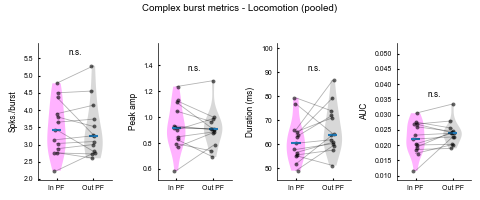

Quiet Spks./burst (complex paired t-test): n=18, stat=-0.621, p=0.543, shapiro_p=0.0778
Quiet Peak amp (complex paired t-test): n=18, stat=-1.4, p=0.178, shapiro_p=0.24
Quiet Duration (ms) (complex paired t-test): n=18, stat=-2.69, p=0.0156, shapiro_p=0.416
Quiet AUC (complex wilcoxon): n=18, stat=16, p=0.00129, shapiro_p=0.00599
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/ComplexBurstMetrics_rest_pooled.svg


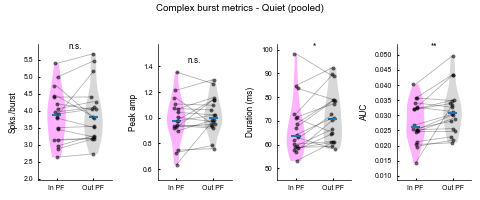

In [5]:
# Plot pooled burst metrics

metric_data = metric_data_pooled
cond_counts = cond_counts_pooled
condition_labels = ['In PF', 'Out PF']

# Compute global y limits
metric_ylim = {}
for metric, _ in metric_specs:
    all_vals = []
    for cond in conditions:
        all_vals.append(np.asarray(metric_data['complex'][metric][cond], dtype=float))
        if include_simple_bursts:
            all_vals.append(np.asarray(metric_data['simple'][metric][cond], dtype=float))
    metric_ylim[metric] = _global_ylim(all_vals)

panel_w = 1.2
panel_h = 2
panel_w_eff = panel_w * (1.5 if include_simple_bursts else 1.0)

state_specs = [
    ('run', 'Locomotion'),
    ('rest', 'Quiet'),
]

for state_key, state_label in state_specs:
    fig, axes = plt.subplots(1, 4, figsize=(panel_w_eff * 4, panel_h), sharex=True, sharey=False)
    conds = [f"{state_key}_in", f"{state_key}_out"]

    counts_in_complex = np.asarray(cond_counts['complex'][conds[0]], dtype=float)
    counts_out_complex = np.asarray(cond_counts['complex'][conds[1]], dtype=float)
    pair_mask_complex = (
        (counts_in_complex >= min_bursts_per_condition)
        & (counts_out_complex >= min_bursts_per_condition)
    )

    if include_simple_bursts:
        counts_in_simple = np.asarray(cond_counts['simple'][conds[0]], dtype=float)
        counts_out_simple = np.asarray(cond_counts['simple'][conds[1]], dtype=float)
        pair_mask_simple = (
            (counts_in_simple >= min_bursts_per_condition)
            & (counts_out_simple >= min_bursts_per_condition)
        )

    for ax, (metric_key, ylabel) in zip(axes, metric_specs):
        vals_in_complex = np.asarray(metric_data['complex'][metric_key][conds[0]], dtype=float)
        vals_out_complex = np.asarray(metric_data['complex'][metric_key][conds[1]], dtype=float)
        if pair_mask_complex.size > 0:
            vals_in_complex = vals_in_complex[pair_mask_complex]
            vals_out_complex = vals_out_complex[pair_mask_complex]
        else:
            vals_in_complex = np.array([], dtype=float)
            vals_out_complex = np.array([], dtype=float)

        plot_data = []
        positions = [1, 2]
        colors = ['magenta', 'gray']
        alphas = [0.3, 0.3]

        for vals in [vals_in_complex, vals_out_complex]:
            finite = vals[np.isfinite(vals)]
            if finite.size == 0:
                finite = np.array([np.nan])
            plot_data.append(finite)

        if include_simple_bursts:
            vals_in_simple = np.asarray(metric_data['simple'][metric_key][conds[0]], dtype=float)
            vals_out_simple = np.asarray(metric_data['simple'][metric_key][conds[1]], dtype=float)
            if pair_mask_simple.size > 0:
                vals_in_simple = vals_in_simple[pair_mask_simple]
                vals_out_simple = vals_out_simple[pair_mask_simple]
            else:
                vals_in_simple = np.array([], dtype=float)
                vals_out_simple = np.array([], dtype=float)

            for vals in [vals_in_simple, vals_out_simple]:
                finite = vals[np.isfinite(vals)]
                if finite.size == 0:
                    finite = np.array([np.nan])
                plot_data.append(finite)

            positions.extend([3.5, 4.5])
            colors.extend(['magenta', 'gray'])
            alphas.extend([0.15, 0.15])

        if any(len(arr) < 2 for arr in plot_data):
            print(f"{state_label} {ylabel}: not enough data for violinplot")
            ax.axis("off")
            continue
        parts = ax.violinplot(plot_data, positions=positions, showmedians=True, showextrema=False)
        for body, color, alpha in zip(parts['bodies'], colors, alphas):
            body.set_facecolor(color)
            body.set_edgecolor('none')
            body.set_alpha(alpha)

        n_pairs = min(len(vals_in_complex), len(vals_out_complex))
        for i in range(n_pairs):
            if np.isfinite(vals_in_complex[i]) and np.isfinite(vals_out_complex[i]):
                ax.plot([1, 2], [vals_in_complex[i], vals_out_complex[i]], color='black', alpha=0.3, linewidth=0.6)

        rng = np.random.default_rng(0)
        for pos, vals in zip([1, 2], [vals_in_complex, vals_out_complex]):
            finite_mask = np.isfinite(vals)
            if not np.any(finite_mask):
                continue
            jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
            xs = pos + jitter
            ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.6, linewidths=0)

        p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in_complex, vals_out_complex)
        sig_label = _sig_label(p_val)
        if np.isfinite(p_val):
            print(
                f"{state_label} {ylabel} (complex {test_name}): n={n_valid}, "
                f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
            )
        else:
            print(f"{state_label} {ylabel} (complex): n={n_valid} (insufficient valid pairs)")
        if sig_label:
            y_vals = np.concatenate([
                vals_in_complex[np.isfinite(vals_in_complex)],
                vals_out_complex[np.isfinite(vals_out_complex)],
            ])
            if y_vals.size > 0:
                y_max = np.nanmax(y_vals)
                y_min = np.nanmin(y_vals)
                y_span = y_max - y_min if y_max != y_min else 1.0
                y_star = y_max + 0.08 * y_span
                ylim = metric_ylim.get(metric_key)
                if ylim is not None:
                    y0, y1 = ylim
                    y_span_global = y1 - y0 if y1 != y0 else 1.0
                    y_star = min(y_star, y1 - 0.05 * y_span_global)
                ax.text(1.5, y_star, sig_label, ha='center', va='bottom', fontsize=6, fontname='Arial')

        if include_simple_bursts:
            n_pairs_simple = min(len(vals_in_simple), len(vals_out_simple))
            for i in range(n_pairs_simple):
                if np.isfinite(vals_in_simple[i]) and np.isfinite(vals_out_simple[i]):
                    ax.plot([3.5, 4.5], [vals_in_simple[i], vals_out_simple[i]], color='black', alpha=0.2, linewidth=0.6)

            for pos, vals in zip([3.5, 4.5], [vals_in_simple, vals_out_simple]):
                finite_mask = np.isfinite(vals)
                if not np.any(finite_mask):
                    continue
                jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
                xs = pos + jitter
                ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.4, linewidths=0)

            p_val_s, stat_s, test_s, n_s, shapiro_s = _paired_test(vals_in_simple, vals_out_simple)
            sig_label_s = _sig_label(p_val_s)
            if np.isfinite(p_val_s):
                print(
                    f"{state_label} {ylabel} (simple {test_s}): n={n_s}, "
                    f"stat={stat_s:.3g}, p={p_val_s:.3g}, shapiro_p={shapiro_s:.3g}"
                )
            else:
                print(f"{state_label} {ylabel} (simple): n={n_s} (insufficient valid pairs)")
            if sig_label_s:
                y_vals = np.concatenate([
                    vals_in_simple[np.isfinite(vals_in_simple)],
                    vals_out_simple[np.isfinite(vals_out_simple)],
                ])
                if y_vals.size > 0:
                    y_max = np.nanmax(y_vals)
                    y_min = np.nanmin(y_vals)
                    y_span = y_max - y_min if y_max != y_min else 1.0
                    y_star = y_max + 0.08 * y_span
                    ylim = metric_ylim.get(metric_key)
                    if ylim is not None:
                        y0, y1 = ylim
                        y_span_global = y1 - y0 if y1 != y0 else 1.0
                        y_star = min(y_star, y1 - 0.05 * y_span_global)
                    ax.text(4.0, y_star, sig_label_s, ha='center', va='bottom', fontsize=6, fontname='Arial')

            ax.set_xticks([1, 2, 3.5, 4.5])
            ax.set_xticklabels(condition_labels + condition_labels, fontsize=5, fontname='Arial')
            ax.set_xlim(0.5, 5.0)
        else:
            ax.set_xticks([1, 2])
            ax.set_xticklabels(condition_labels, fontsize=5, fontname='Arial')
            ax.set_xlim(0.5, 2.5)

        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.tick_params(labelsize=5)
        ylim = metric_ylim.get(metric_key)
        if ylim is not None:
            ax.set_ylim(*ylim)
        for label in list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(f"Complex burst metrics - {state_label} (pooled)", fontsize=7, fontname='Arial')
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out_path = os.path.join(
        figure_save_folder,
        f"ComplexBurstMetrics_{state_key}_pooled.svg",
    )
    fig.savefig(out_path, dpi=300)
    print(f"Saved to {out_path}")
    plt.show()

In [6]:
# Summary statistics
print('\n=== Summary Statistics ===')

for burst_type in ['complex', 'simple']:
    print(f'\n{burst_type.capitalize()} bursts:')
    for metric, ylabel in metric_specs:
        print(f'  {ylabel}:')
        for cond in conditions:
            vals = np.asarray(metric_data_pooled[burst_type][metric][cond], dtype=float)
            finite = vals[np.isfinite(vals)]
            if finite.size > 0:
                print(f'    {cond}: n={finite.size}, mean={np.mean(finite):.3f}, sem={stats.sem(finite):.3f}')
            else:
                print(f'    {cond}: no valid data')


=== Summary Statistics ===

Complex bursts:
  Spks./burst:
    run_in: n=17, mean=3.586, sem=0.206
    run_out: n=13, mean=3.442, sem=0.222
    rest_in: n=19, mean=3.872, sem=0.170
    rest_out: n=19, mean=3.889, sem=0.188
  Peak amp:
    run_in: n=17, mean=0.944, sem=0.038
    run_out: n=13, mean=0.911, sem=0.040
    rest_in: n=19, mean=1.011, sem=0.047
    rest_out: n=19, mean=1.034, sem=0.033
  Duration (ms):
    run_in: n=17, mean=64.351, sem=2.673
    run_out: n=13, mean=66.372, sem=2.718
    rest_in: n=19, mean=68.079, sem=2.701
    rest_out: n=19, mean=72.580, sem=2.500
  AUC:
    run_in: n=17, mean=0.024, sem=0.002
    run_out: n=13, mean=0.024, sem=0.001
    rest_in: n=19, mean=0.029, sem=0.002
    rest_out: n=19, mean=0.032, sem=0.002

Simple bursts:
  Spks./burst:
    run_in: no valid data
    run_out: no valid data
    rest_in: no valid data
    rest_out: no valid data
  Peak amp:
    run_in: no valid data
    run_out: no valid data
    rest_in: no valid data
    rest_out: